# СКОРОСТЬ ОТ ВРЕМЕНИ
См. ниже время ограничена t < 0.0004, поскольку большинство бэгов разрываются именно в этом диапазоне 

In [1]:
import bags_array_sphere as bg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm 
from scipy.optimize import minimize, curve_fit
from scipy.stats import gaussian_kde 

In [2]:
df = pd.read_excel(r"C:\Users\misha\Desktop\science_code\geo_physics_research\new_output_2.xlsx").dropna()
df = df[df['t'] < 5e-4]
# df = df[ 5e-5 < df['t']]

[1.88013563e+04 3.09966956e+00]
[9.14458396e+03 4.64115857e+00]
[1.02998593e+04 5.69721513e+00]
[6.19733778e+04 1.80819383e+00]


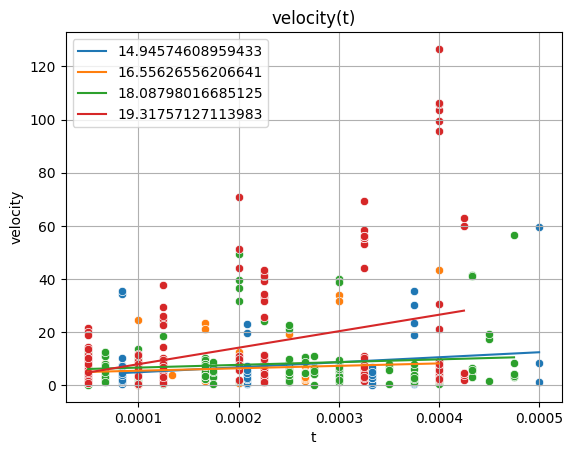

In [9]:
df_temp = df
for name, group in df_temp.groupby(by='wind_velocity'):
    sns.scatterplot(x=group['t'], y = group['velocity'])
    coefficients = np.polyfit(group['t'],group['velocity'], 1)
    t = np.linspace(min(group['t']), max(group['t']), 100)
    velocity = coefficients[0]*t  + coefficients[1]
    sns.lineplot(y=velocity,x = t, label = name)
    print(coefficients)
plt.grid()
plt.title('velocity(t)')
plt.legend()
plt.show()

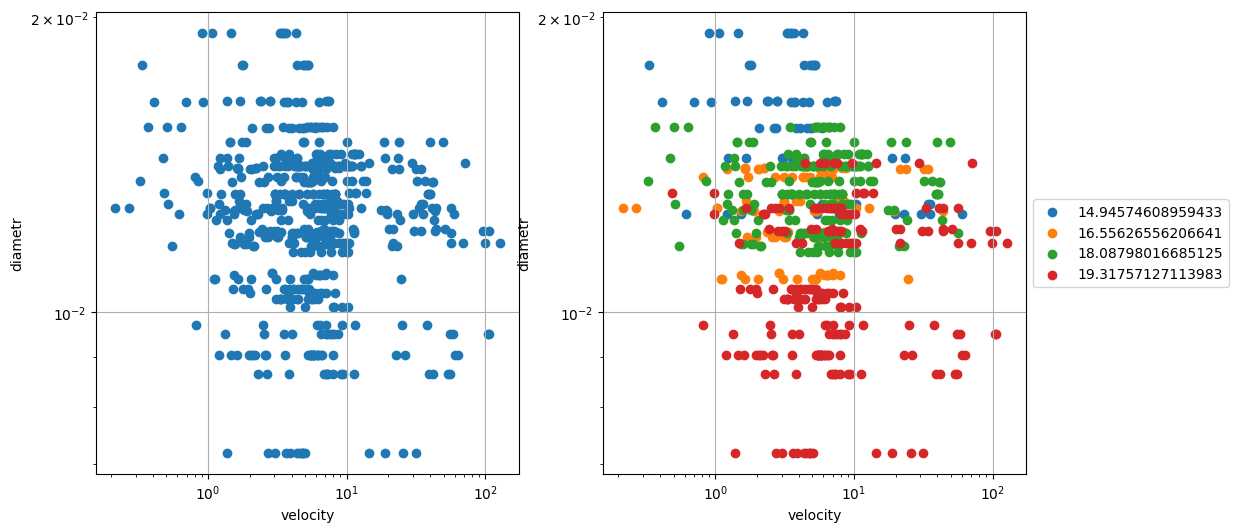

In [4]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(df['velocity'], df['diametr'])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('velocity')
ax[0].set_ylabel('diametr')
ax[0].grid()

for name, group in df.groupby(by='wind_velocity'):
    ax[1].scatter(group['velocity'], group['diametr'], label = name)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('velocity')
ax[1].set_ylabel('diametr')
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].grid()


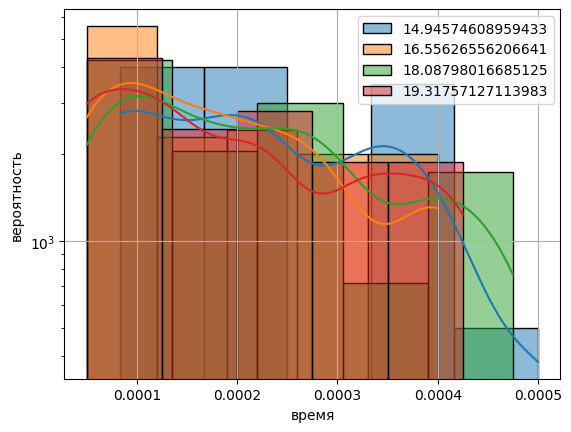

In [5]:
for name, group in df.groupby(by='wind_velocity'):
    sns.histplot(x = group['t'], kde = True, stat='density',label = name, bins = 5)
plt.yscale('log')
plt.xlabel('время')
plt.ylabel('вероятность')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [10]:
print(list(df[df['velocity'] > 20]['source_path']))

['C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_13.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_2.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_2.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_2.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_2.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_6.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F33\\F33_12000/F33_12000_6.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F37\\F37_15000_20_11_2025/F37_15000_005_20_11_25.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F37\\F37_15000_20_11_2025/F37_15000_005_20_11_25.dat', 'C:\\Users\\misha\\Desktop\\science_code\\data\\clear_water\\F37\\F37_15000_20_11_2025/F37_15000_005_20_11_2

Максимальное значение: 1.3212530015221091


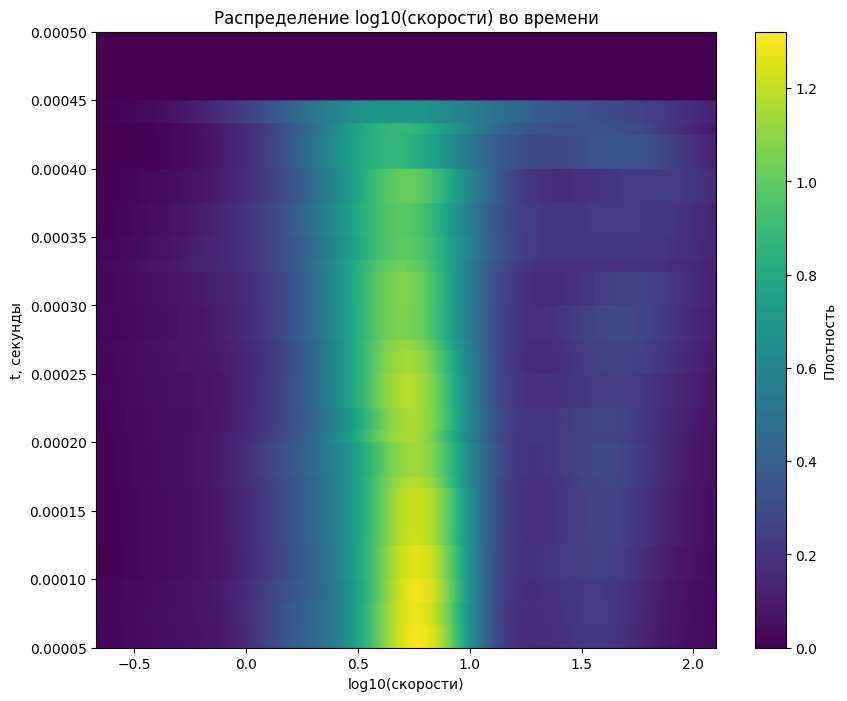

In [7]:
# Упрощаем: меньше точек для отладки
num = 1000
n_time = num
n_thick = num

df['thickness'] = (2*0.0728)/(1000*df['velocity']**2)
df['velocity_log10'] = np.log10(df['velocity'])

t = np.linspace(min(df['t']), max(df['t']), n_time)
velocity_log10 = np.linspace(min(df['velocity_log10']), max(df['velocity_log10']), n_thick)

grid_log10 = np.zeros([n_time, n_thick])

dt = 0.001  # увеличиваем окно для захвата большего числа точек

for i, time in enumerate(t):
    df_time = df[(df['t'] > time) & (df['t'] < time + dt)]
    if len(df_time) > 10:  # увеличиваем порог
        kde = gaussian_kde(df_time['velocity_log10'])
        grid_log10[i, :] = kde(velocity_log10)
    else:
        # Если данных мало, ставим маленькие случайные значения
        grid_log10[i, :] = np.zeros(n_thick)

print(f"Максимальное значение: {grid_log10.max()}")

# Рисуем
plt.figure(figsize=(10, 8))
plt.imshow(grid_log10, 
           extent=[min(velocity_log10), max(velocity_log10), min(t), max(t)], 
           aspect='auto',
           origin='lower',
           cmap='viridis')
plt.ylabel('t, секунды')
plt.xlabel('log10(скорости)')
plt.colorbar(label='Плотность')
plt.title('Распределение log10(скорости) во времени')
plt.show()

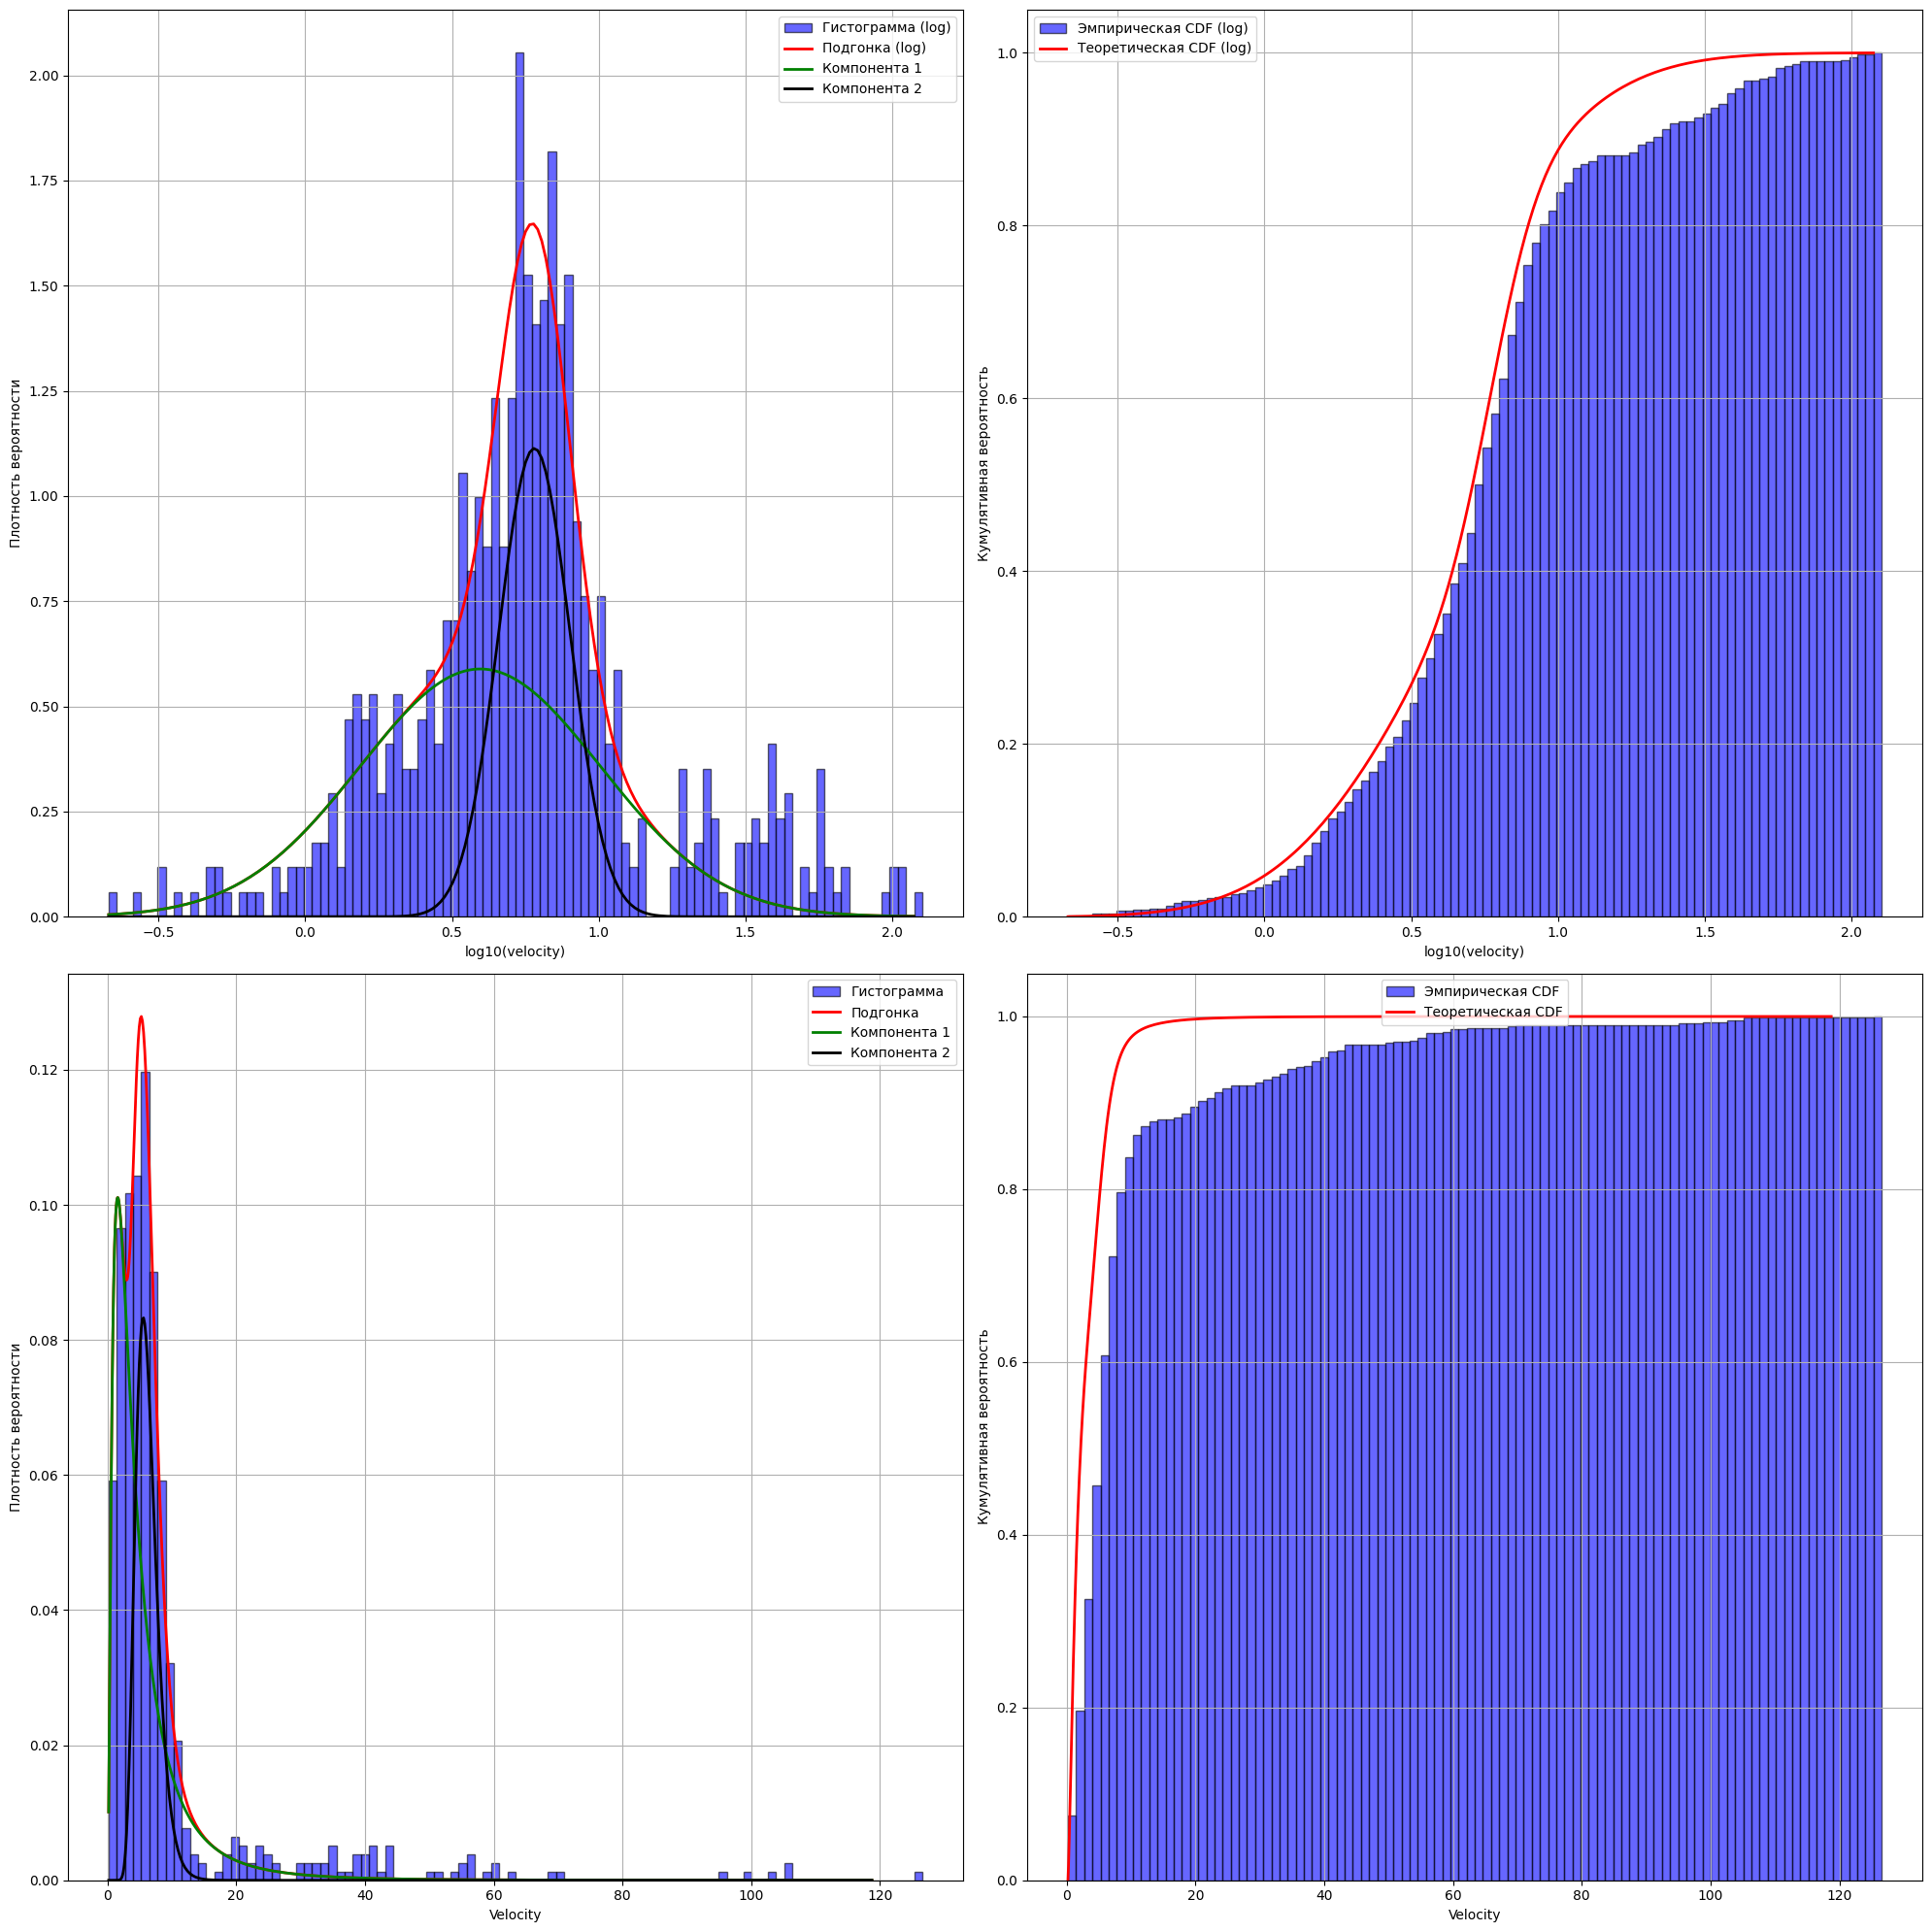

In [8]:
BINS=100

velocity = np.linspace(0, max(df['velocity']), BINS)

df['velocity_log10'] = np.log10(df['velocity'])
velocity_log10 = np.linspace(0, max(df['velocity_log10']), BINS)

prob, bin_edges = np.histogram(df['velocity_log10'], bins=BINS, density=True)
velocity_log10_for_prob = bin_edges[:-1]

# Функция с двумя нормальными распределениями + веса
def double_norm_func(x, loc1, scale1, amp1, loc2, scale2, amp2):
    return (amp1 * norm.pdf(x, loc1, scale1) + 
            amp2 * norm.pdf(x, loc2, scale2))

def double_norm_func_10(x, loc1, scale1, amp1, loc2, scale2, amp2):
    return (amp1 * norm.pdf(10**x, loc1, scale1) + 
            amp2 * norm.pdf(10**x, loc2, scale2))

# Начальные параметры: [loc1, scale1, amp1, loc2, scale2, amp2]
p0 = [0.1, 0.3, 0.5,
      0.7, 0.3, 2] 

# Ограничения (чтобы параметры были разумными)
bounds = (
    [0, 0.01, 0, 0, 0.01, 0],      # Нижние границы
    [3, 3, 3, 3, 3, 3]             # Верхние границы
)

popt, pcov = curve_fit(double_norm_func, velocity_log10_for_prob, prob, 
                       p0=p0, bounds=bounds, maxfev=5000)

loc1, scale1, amp1, loc2, scale2, amp2 = popt

fig, ax = plt.subplots(2,2,figsize=(20,20))

# Для подгонки в log10 пространстве
x_fit_log = np.linspace(velocity_log10_for_prob.min(), velocity_log10_for_prob.max(), 200)
y_fit_log = double_norm_func(x_fit_log, *popt)
y_fit_1_log = amp1 * norm.pdf(x_fit_log, loc1, scale1)
y_fit_2_log = amp2 * norm.pdf(x_fit_log, loc2, scale2)

### График 1: log10 пространство - гистограмма и подгонка
ax[0,0].hist(df['velocity_log10'], bins=BINS, density=True, alpha=0.6, 
             color='blue', edgecolor='black', label='Гистограмма (log)')
ax[0,0].plot(x_fit_log, y_fit_log, 'r-', linewidth=2, label='Подгонка (log)')
ax[0,0].plot(x_fit_log, y_fit_1_log, 'g-', linewidth=2, label='Компонента 1')
ax[0,0].plot(x_fit_log, y_fit_2_log, 'k-', linewidth=2, label='Компонента 2')
ax[0,0].set_xlabel('log10(velocity)')
ax[0,0].set_ylabel('Плотность вероятности')
ax[0,0].legend()
ax[0,0].grid()

### График 2: log10 пространство - кумулятивная функция распределения
ax[0,1].hist(df['velocity_log10'], bins=BINS, density=True, cumulative=True,
             alpha=0.6, color='blue', edgecolor='black', label='Эмпирическая CDF (log)')
ax[0,1].plot(x_fit_log, np.cumsum(np.array(y_fit_log))/np.sum(np.array(y_fit_log)), 
             'r-', linewidth=2, label='Теоретическая CDF (log)')
ax[0,1].set_xlabel('log10(velocity)')
ax[0,1].set_ylabel('Кумулятивная вероятность')
ax[0,1].legend()
ax[0,1].grid()

### Первоначальные скорости (линейная шкала)

# Вычисляем плотность для подгонки в линейном пространстве
x_vel = 10**x_fit_log
y_vel_log = double_norm_func(x_fit_log, *popt)
y_vel = y_vel_log / (x_vel * np.log(10))

# Компоненты в линейном пространстве
y_vel_1 = (amp1 * norm.pdf(x_fit_log, loc1, scale1)) / (x_vel * np.log(10))
y_vel_2 = (amp2 * norm.pdf(x_fit_log, loc2, scale2)) / (x_vel * np.log(10))

### График 3: линейное пространство - гистограмма и подгонка (то что было ax[1,0])
ax[1,0].hist(df['velocity'], bins=BINS, density=True, alpha=0.6,
             color='blue', edgecolor='black', label='Гистограмма')
ax[1,0].plot(x_vel, y_vel, 'r-', linewidth=2, label='Подгонка')
ax[1,0].plot(x_vel, y_vel_1, 'g-', linewidth=2, label='Компонента 1')
ax[1,0].plot(x_vel, y_vel_2, 'k-', linewidth=2, label='Компонента 2')
ax[1,0].set_xlabel('Velocity')
ax[1,0].set_ylabel('Плотность вероятности')
ax[1,0].legend()
ax[1,0].grid()

### График 4: линейное пространство - кумулятивная функция распределения (то что было ax[1,1])
ax[1,1].hist(df['velocity'], bins=BINS, density=True, cumulative=True,
             alpha=0.6, color='blue', edgecolor='black', label='Эмпирическая CDF')
ax[1,1].plot(x_vel, np.cumsum(np.array(y_vel))/np.sum(np.array(y_vel)), 
             'r-', linewidth=2, label='Теоретическая CDF')
ax[1,1].set_xlabel('Velocity')
ax[1,1].set_ylabel('Кумулятивная вероятность')
ax[1,1].legend()
ax[1,1].grid()

plt.tight_layout()
plt.show()
